In [1]:
import numpy as np
import pandas as pd
import os
#importing libraries

In [2]:
df = pd.read_csv("heart.csv", header=0)
#load dataframe

In [3]:
df.head(5)
#view first rows of dataset

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.shape
#observations/features

(918, 12)

In [5]:
df.dtypes
#figure out which are categorical and which are not

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [6]:
df.describe()
#average age of patients is 53.5

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
df.isnull().any(axis=1)
#check if any values are null, row by row.

0      False
1      False
2      False
3      False
4      False
       ...  
913    False
914    False
915    False
916    False
917    False
Length: 918, dtype: bool

In [8]:
df.isnull().any(axis=1).sum()

np.int64(0)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
#import libraries for visualization

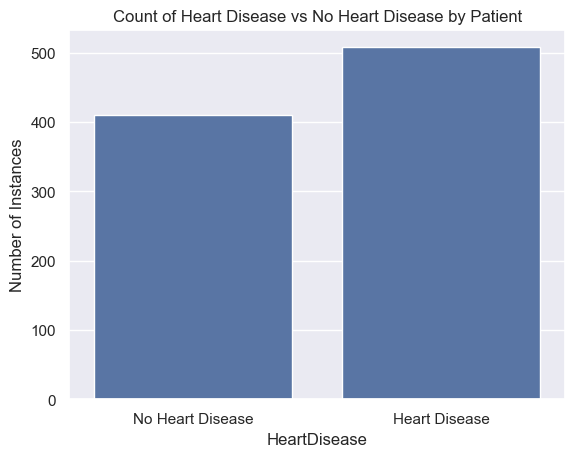

In [10]:
ax = sns.countplot(data=df, x='HeartDisease')
plt.title('Count of Heart Disease vs No Heart Disease by Patient')
ax.set_xticks([0,1])
ax.set_xticklabels(['No Heart Disease', 'Heart Disease'])
plt.ylabel('Number of Instances')
plt.show()


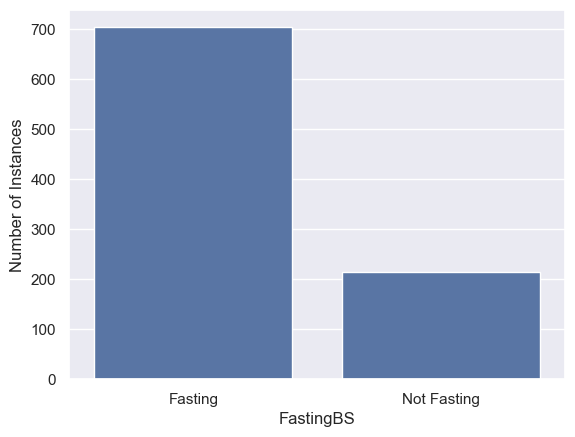

In [11]:
ax = sns.countplot(data=df, x='FastingBS')
ax.set_xticks([0,1])
ax.set_xticklabels(['Fasting', 'Not Fasting'])
plt.ylabel('Number of Instances')
plt.show()
#worth noting that more patients in the dataset actually were 
# even in number when it came to heart disease,
# but much more skew when it came
# to Fasting

In [12]:
df_heart_disease = df[df['HeartDisease'] == 1]
df_heart_disease[(df_heart_disease['Age']>50) & (df_heart_disease['Sex'] =='M')].shape[0]/df.shape[0]
#what percent of patients with heart disease are male and over 50?

0.3747276688453159

In [13]:
median_diag_with_HD = df_heart_disease['Age'].median()
median_diag_with_HD
#median age of patients with a heart disease

57.0

In [14]:
count_zero_restingBP = df[df['RestingBP'] == 0].shape[0]
count_zero_restingBP
# df[boolean series] = filtered df
# counting the number of zero_resting BP in the set



1

In [15]:
count_zero_Cholesterol = df[df['Cholesterol'] == 0].shape[0]
count_zero_Cholesterol
#counting the number of zero cholesterol in the set

172

In [16]:
medians = df.groupby('HeartDisease')['Cholesterol'].median()
medians
df['Cholesterol'] = np.where((df['Cholesterol'] == 0) & (df['HeartDisease'] == 0), medians[0], df['Cholesterol'])
df['Cholesterol'] = np.where((df['Cholesterol'] == 0) & (df['HeartDisease'] == 1), medians[1], df['Cholesterol'])
(df['Cholesterol'] == 0).sum()
#imputing by using the medians

np.int64(0)

In [17]:
medians = df.groupby('HeartDisease')['RestingBP'].median()
medians
df['RestingBP'] = np.where((df['RestingBP'] == 0) & (df['HeartDisease'] == 0),medians[0] ,df['RestingBP'])
df['RestingBP'] = np.where((df['RestingBP'] == 0) & (df['HeartDisease'] == 1),medians[1] ,df['RestingBP'])
(df['RestingBP'] == 0).sum()
#imputing by using the medians

np.int64(0)

In [18]:
#one hot encoding.

df['ChestPainType'].unique() # array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)
df['RestingECG'].unique() #array(['Normal', 'ST', 'LVH'], dtype=object)
df['ST_Slope'].unique() #array(['Up', 'Flat', 'Down'], dtype=object)
# these are good columns to one-hot encode
#ChestPainType, RestingECG, ST_Slope
#These features have a small range of possible classifications, making them a strong candidate for one-hot encoding.
#these are columns that need to be converted into numbers
#Sex, Exercise Angina
to_encode = ['ChestPainType', 'RestingECG', 'ST_Slope']
#encode data and cleanup
df = pd.get_dummies(df, columns=to_encode)
#i dont like true/false showing up in my data
cols = df.select_dtypes(include='bool').columns
for col in cols:
    df[col] = np.where(df[col] == True, 1, 0)






In [19]:
dummies = ['Sex', 'ExerciseAngina']
df = pd.get_dummies(df, columns=dummies, drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
for col in bool_cols:
    df[col] = np.where(df[col] == True, 1, 0)

In [20]:
df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Sex_M,ExerciseAngina_Y
0,40,140.0,289.0,0,172,0.0,0,0,1,0,0,0,1,0,0,0,1,1,0
1,49,160.0,180.0,0,156,1.0,1,0,0,1,0,0,1,0,0,1,0,0,0
2,37,130.0,283.0,0,98,0.0,0,0,1,0,0,0,0,1,0,0,1,1,0
3,48,138.0,214.0,0,108,1.5,1,1,0,0,0,0,1,0,0,1,0,0,1
4,54,150.0,195.0,0,122,0.0,0,0,0,1,0,0,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,0,0,0,1,0,1,0,0,1,0,1,0
914,68,144.0,193.0,1,141,3.4,1,1,0,0,0,0,1,0,0,1,0,1,0
915,57,130.0,131.0,0,115,1.2,1,1,0,0,0,0,1,0,0,1,0,1,1
916,57,130.0,236.0,0,174,0.0,1,0,1,0,0,1,0,0,0,1,0,0,0


<Axes: >

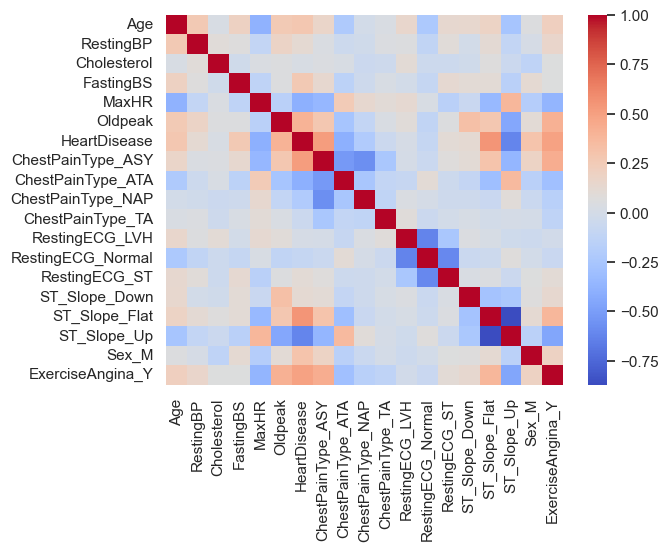

In [21]:
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm')
#Looks like ExerciseAngina_Y, Sex_M, ST_Slope_Flat, Chest_Pain_Type_ASY, Oldpeak are reasonably correlated.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV

In [23]:
y = df['HeartDisease']
X = df.drop(columns='HeartDisease')
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=1234)

In [24]:
#Finding optimal hyperparameter
nn = [2 ** n for n in range(10)]
acc =[]
for item in nn:
    model = KNeighborsClassifier(n_neighbors=item)
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    acc_score = accuracy_score(y_test, prediction)
    print('Nearest Neighbor value:', item, 'Accuracy:', acc_score)
    acc.append(acc_score)
#16/32 is the best hyperparameter for this.


Nearest Neighbor value: 1 Accuracy: 0.6702898550724637
Nearest Neighbor value: 2 Accuracy: 0.6702898550724637
Nearest Neighbor value: 4 Accuracy: 0.7282608695652174
Nearest Neighbor value: 8 Accuracy: 0.7137681159420289
Nearest Neighbor value: 16 Accuracy: 0.7210144927536232
Nearest Neighbor value: 32 Accuracy: 0.7210144927536232
Nearest Neighbor value: 64 Accuracy: 0.6956521739130435
Nearest Neighbor value: 128 Accuracy: 0.6884057971014492
Nearest Neighbor value: 256 Accuracy: 0.6884057971014492
Nearest Neighbor value: 512 Accuracy: 0.5615942028985508


In [25]:
#Finding feature with the most predictive power.
selected_features = ['ExerciseAngina_Y', 'Sex_M', 'ST_Slope_Flat', 'ChestPainType_ASY', 'Oldpeak']
acc =[]
for item in selected_features:
    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(X_train[[item]], y_train)
    prediction = model.predict(X_test[[item]])
    acc_score = accuracy_score(y_test, prediction)
    print('Feature:', item, 'Accuracy:', acc_score)
    acc.append(acc_score)
#looks like ST_Slope_Flat was the best here (83.6)

Feature: ExerciseAngina_Y Accuracy: 0.7536231884057971
Feature: Sex_M Accuracy: 0.6594202898550725
Feature: ST_Slope_Flat Accuracy: 0.8369565217391305
Feature: ChestPainType_ASY Accuracy: 0.8043478260869565
Feature: Oldpeak Accuracy: 0.6811594202898551


In [26]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = KNeighborsClassifier(n_neighbors=16)
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)
acc_score = accuracy_score(y_test, predictions)
print('Score:' , acc_score)
#I'm worried of overfitting, not quite sure how normalization made such a drastic change.


Score: 0.894927536231884


In [27]:
#realized i can find optimal hyperparameters with GridSearchCV
param_grid = {'n_neighbors' : [n for n in range(1, 50)],
              'weights' : ['uniform', 'distance'],
              'metric': ['euclidean', 'manhattan', 'minkowski']
}
model = KNeighborsClassifier()
X_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)
grid = GridSearchCV(model, param_grid, cv=5)
grid_search = grid.fit(X_train_scaled, y_train)


In [28]:
# Print best-performing hyperparameter configuration
print('Optimal hyperparameters: {0}'.format(grid_search.best_params_))

# print best accuracy score resulting from this configuration
print('Accuracy score: {0}'.format(grid_search.best_score_))

Optimal hyperparameters: {'metric': 'manhattan', 'n_neighbors': 47, 'weights': 'uniform'}
Accuracy score: 0.8597141472868216


In [45]:
#really wanted to test it out ngl
best_model = grid_search.best_estimator_
new_data = pd.DataFrame({
    'Age': [14],
    'RestingBP' : [80],
    'Cholesterol' : [200],
    'FastingBS' : [0],
    'MaxHR' : [206] ,
    'Oldpeak' : [1.0] ,
    'ChestPainType_ASY' : [0],
    'ChestPainType_ATA' : [0],
    'ChestPainType_NAP' : [1],
    'ChestPainType_TA' : [0],
    'RestingECG_LVH' : [0],
    'RestingECG_Normal' : [1],
    'RestingECG_ST' : [0],
    'ST_Slope_Down' : [0],
    'ST_Slope_Flat' : [1],
    'ST_Slope_Up' : [0],
    'Sex_M' : [1],
    'ExerciseAngina_Y' : [1]
})
new_data_scaled = scaler.transform(new_data)
prediction = best_model.predict(new_data_scaled)
if prediction == 1:
    print('This patient is suspected to have a Heart Disease')
else: 
    print('This patient is not suspected to have a Heart Disease')

This patient is suspected to have a Heart Disease


In [48]:
#saving these models
import pickle
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)